<a id="top"></a>
# 🗺️ Spatial Crime Analysis — Biobío Region, Chile
### José Ignacio Soto Bastías | Mining Engineer · Data Scientist

Spatial autocorrelation analysis of high-connotation crime across the 33 communes
of the Biobío Region (2023), using Moran's I, LISA clustering, and choropleth mapping.

**Tools:** Python · GeoPandas · PySAL · Matplotlib

---

## Table of Contents
1. [Summary](#summary)
2. [Data Source & Context](#data)
3. [Environment Setup & Data Loading](#setup)
4. [Descriptive Analysis](#descriptive)
5. [B.2 Choropleth Map](#choropleth)
6. [B.3 Moran's I — Global Spatial Autocorrelation](#moran)
7. [B.4 LISA — Local Spatial Autocorrelation](#lisa)
8. [B.5 Discussion & Implications](#discussion)

<a id='summary'></a>
##Summary

This study analyzes the spatial distribution of high-connotation social crimes (variable `F2023`) across the 33 communes of the Biobío Region during 2023.
Descriptive results and choropleth mapping reveal a strong concentration of crime in urban zones, highlighting two primary hotspots: **Greater Concepción** (led by Concepción, Talcahuano, and Hualpén) and the **Los Ángeles / Mulchén / Laja / Cabrero** area. In contrast, rural communes, especially those in the highlands and southern coastal areas, show consistently low values.

The **Global Moran's I** (0.1097, p ≈ 0.096) indicates a weak positive spatial autocorrelation, although it is not statistically significant at the regional level.
**LISA analysis** identifies significant local clusters (p < 0.05): HH in Laja and Cabrero, LL in Alto Biobío, Santa Bárbara, and Antuco, and an HL outlier in Mulchén.

These findings confirm a clear link between higher population density, economic activity, and regional importance with higher crime levels. This justifies the implementation of targeted prevention policies and a strategic allocation of law enforcement resources, prioritizing the identified urban hotspots.

<a id="data"></a>
## Phenomenon and Data Source

This analysis focuses on the communes of the Biobío Region to explore the existence of **spatial autocorrelation** in crime levels. Specifically, distinct patterns are expected based on the degree of rurality or urbanity:

* **Rural communes** -> lower crime rates -> tendency toward low–low (LL) clustering.
* **Urban and semi-urban communes** (Greater Concepción, Los Ángeles) -> higher crime rates -> tendency toward high–high (HH) clustering.

The data consists of indicators for **high-connotation social crimes** (DACS) per commune, sourced from the ArcGIS Feature Server of the Center for Interdisciplinary Studies in Geography and Territory at UC (CEDIT_GEOUC):  
> https://services2.arcgis.com/cRH3tEMPESJz6DMX/arcgis/rest/services/Map_Delitos_Comuna_WFL1/FeatureServer

<a id='setup'></a>
## 1. Environment Setup & Data Loading

In [26]:
# ── Core libraries ──────────────────────────────────────────────────────────
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from matplotlib import patheffects

# ── Spatial analysis (PySAL ecosystem) ─────────────────────────────────────
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster, plot_local_autocorrelation

### Data Acquisition and Reproducibility

To ensure this analysis is fully reproducible, the following block automates the data retrieval process. It performs three main tasks:
1. **Environment Sanitization**: Clears previous temporary files to ensure a fresh execution.
2. **Remote Retrieval**: Downloads the required spatial datasets (Shapefiles) directly from the project's GitHub repository.
3. **Automated Extraction**: Unpacks the compressed data and identifies the primary spatial components for analysis.

*Note: No manual file uploads are required to run this notebook.*

In [27]:
# ── 1. Environment Sanitization ─────────────────────────────────────────────
# This clears previous runs to ensure the download starts from a clean state
to_clean = ["delitos_biobio.zip", "mapa_data"]

for item in to_clean:
    if os.path.exists(item):
        if os.path.isdir(item):
            shutil.rmtree(item)
        else:
            os.remove(item)
        print(f"🧹 Sanitization: Removed old {item}")

# ── 2. Download & load spatial data from GitHub ──────────────────────────────
DATA_URL    = "https://github.com/josesotob/data-science-portfolio/raw/refs/heads/main/delitos_biobio.zip"
ZIP_PATH    = "delitos_biobio.zip"
EXTRACT_DIR = "mapa_data"
CRIME_COL   = "F2023"

print("📥 Downloading spatial data from GitHub...")
response = requests.get(DATA_URL, timeout=30)
response.raise_for_status()

with open(ZIP_PATH, "wb") as f:
    f.write(response.content)

print("📂 Extracting ZIP...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

# Locate .shp (case-insensitive)
shp_files = [
    os.path.join(root, f)
    for root, _, files in os.walk(EXTRACT_DIR)
    for f in files if f.lower().endswith(".shp")
]

if not shp_files:
    raise FileNotFoundError("No .shp file found inside the ZIP.")

gdf = gpd.read_file(shp_files[0])
print(f"✅ Shapefile loaded: {shp_files[0]}")
print(f"   {len(gdf)} communes | Original CRS: {gdf.crs}")

# ── 3. Coordinate System Management ─────────────────────────────────────────
# Reproject to UTM Zone 19S for metric calculations (Essential for distance-based weights)
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")

gdf = gdf.to_crs("EPSG:32719")
print(f"🚀 Reprojected to: {gdf.crs}")

gdf.head()

🧹 Sanitization: Removed old delitos_biobio.zip
🧹 Sanitization: Removed old mapa_data
📥 Downloading spatial data from GitHub...
📂 Extracting ZIP...
✅ Shapefile loaded: mapa_data/Delitos de Alta Connotación Social/DelitosAltaConnotacion.shp
   33 communes | Original CRS: EPSG:3857
🚀 Reprojected to: EPSG:32719


,OBJECTID_1,CUT_REG,CUT_PROV,CUT_COM,REGION,PROVINCIA,COMUNA,SUPERFICIE,Comuna_1,Comuna_OK_,...,F2018,F2019,F2020,F2021,F2022,F2023,ObjectID,Shape__Are,Shape__Len,geometry
0,3,08,083,08308,Biobío,Biobío,Quilaco,1123.97,Quilaco,Quilaco,...,885.6,1412.5,1148.6,1481.1,1026.7,477.7,248,1.811128e+09,353939.768938,"POLYGON ((258303.103 5798453.431, 258211.681 5..."
1,8,08,083,08311,Biobío,Biobío,Santa Bárbara,1250.94,Santa Bárbara,Santa Bárbara,...,1531.1,1505.1,1048.5,1066.7,1686.7,907.4,303,1.997400e+09,287029.513783,"POLYGON ((292256.273 5840960.461, 292256.339 5..."
2,12,08,083,08309,Biobío,Biobío,Quilleco,1117.80,Quilleco,Quilleco,...,886.7,1126.5,737.6,598.6,1009.0,540.0,250,1.776082e+09,299912.544527,"POLYGON ((256488.118 5860311.565, 256488.124 5..."
3,42,08,081,08111,Biobío,Concepción,Tomé,494.26,Tomé,Tomé,...,1852.7,2086.6,1462.7,1166.9,1793.9,939.6,323,7.687096e+08,183444.132959,"MULTIPOLYGON (((141958.697 5944097.203, 141949..."
4,43,08,081,08108,Biobío,Concepción,San Pedro de la Paz,112.87,San Pedro de la Paz,San Pedro de la Paz,...,1842.0,1656.9,1293.3,1083.3,1763.7,867.4,298,1.767466e+08,66078.522252,"POLYGON ((135987.887 5905687.549, 135950.331 5..."


<a id='descriptive'></a>
## 2. Descriptive Analysis of the Crime Variable

Before proceeding with the spatial analysis, a preliminary descriptive analysis of the primary variable-communal criminal load (`F2023`), is performed. This Exploratory Data Analysis (EDA) is a critical step to understand the data distribution across the Biobío Region, identify statistical outliers, and detect initial concentrations that may influence the subsequent spatial results.

Two summary tables are presented below:
1. **General Summary Statistics** of the crime variable.
2. **Top 10 Communes Ranking** based on criminal load.

In [28]:
# Table 1: Descriptive Statistics
# Generating a transposed summary table for better readability
summary_stats = gdf[CRIME_COL].describe().to_frame().T
summary_stats.columns = ["Count", "Mean", "Std. Dev.", "Min", "25%", "50%", "75%", "Max"]

print("TABLE 1: General Summary Statistics")
display(summary_stats.round(1))

# Table 2: Top 10 Communes Ranking
# Sorting by criminal load to identify local concentrations
top_10_ranking = (
    gdf[["COMUNA", CRIME_COL]]
    .sort_values(by=CRIME_COL, ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Adjusting to 1-based indexing for a standard ranking format
top_10_ranking.index += 1

print("\nTABLE 2: Top 10 Communes Ranking")
display(top_10_ranking)

TABLE 1: General Summary Statistics


,Count,Mean,Std. Dev.,Min,25%,50%,75%,Max
F2023,33.0,1019.1,342.5,477.7,825.8,963.9,1154.2,2178.8



TABLE 2: Top 10 Communes Ranking


,COMUNA,F2023
1,Concepción,2178.8
2,Yumbel,1550.0
3,Los Angeles,1519.8
4,San Rosendo,1486.7
5,Talcahuano,1322.8
6,Hualpén,1196.1
7,Mulchén,1186.2
8,Lota,1158.5
9,Laja,1154.2
10,Cabrero,1154.0


<a id='choropleth'></a>
## Choropleth Map: Spatial Distribution of Criminal Load, Biobío Region (2023)

The choropleth map illustrates the geographical distribution of the `F2023` variable (high-connotation social crime index) at the communal level, utilizing a **quantile** classification and a sequential color palette ranging from light yellow to dark red.

This visualization enables the immediate identification of **hotspots** (high-incidence concentrations) and **coldspots** (low-incidence areas), allowing for the observation of spatial patterns that complement the previous descriptive analysis and set the stage for the quantitative evaluation of spatial autocorrelation (Moran's I) in the following section.

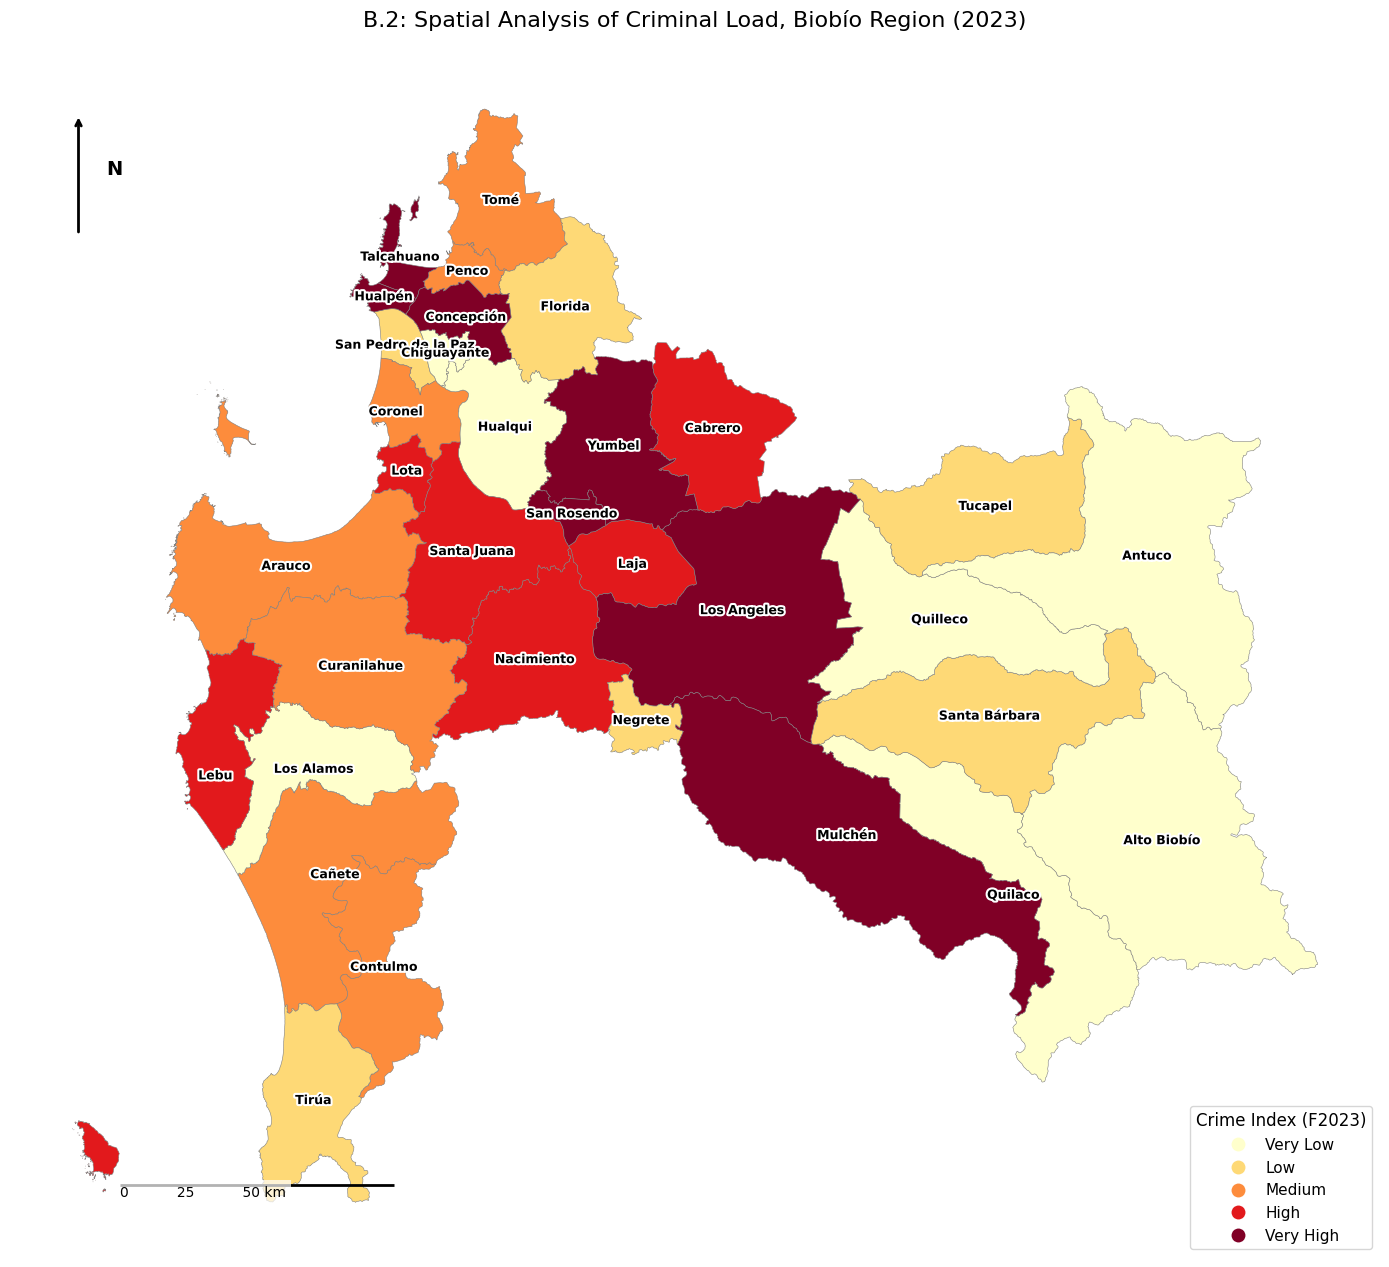

CRS: EPSG:32719
F2023 Range: 477.7 to 2178.8


In [29]:
# Create the figure and axis with a large vertical layout for regional detail
fig, ax = plt.subplots(1, 1, figsize=(14, 18))

# Define the main title with padding to prevent overlap with the map
ax.set_title(
    "B.2: Spatial Analysis of Criminal Load, Biobío Region (2023)",
    fontsize=16, pad=20
)

# Plot the choropleth map using quantile classification (5 classes)
# This highlights relative differences by ensuring an equal number of communes per color
gdf.plot(
    column=CRIME_COL,
    cmap="YlOrRd",
    scheme="Quantiles",
    k=5,
    edgecolor="gray",
    linewidth=0.4,
    ax=ax,
    legend=True,
    legend_kwds={
        "title": "Crime Index (F2023)",
        "loc": "lower right",
        "fontsize": 11,
        "title_fontsize": 12,
        "frameon": True,
        "labels": ["Very Low", "Low", "Medium", "High", "Very High"],
    },
)

# Annotate each commune with its name
# path_effects is used to create a white halo (stroke) for high legibility over the colormap
centroids = gdf.geometry.centroid
for _, row in gdf.iterrows():
    ax.annotate(
        text=row["COMUNA"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center", va="center",
        fontsize=9, fontweight="bold", color="black",
        path_effects=[patheffects.withStroke(linewidth=3, foreground="white")],
    )

# Add a North Arrow to provide geographical orientation
ax.annotate(
    "", xy=(0.05, 0.95), xycoords="axes fraction",
    xytext=(0.05, 0.85), textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=2, color="black")
)
ax.text(0.07, 0.90, "N", transform=ax.transAxes, fontsize=14, fontweight="bold", ha="left")

# Add a manual Scale Bar for distance reference
# Note: Coordinate system must be in meters (UTM) for this scale to be accurate
ax.text(0.08, 0.05, "0           25           50 km", transform=ax.transAxes,
        fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
ax.hlines(y=0.06, xmin=0.08, xmax=0.28, color="black", linewidth=2, transform=ax.transAxes)

# Clean up the plot by removing axis ticks/frames
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Final audit: Verify the Coordinate Reference System and data range
print(f"CRS: {gdf.crs}")
print(f"F2023 Range: {gdf[CRIME_COL].min():.1f} to {gdf[CRIME_COL].max():.1f}")

### Choropleth Map Analysis

The map displays a clear concentration of high crime indices (dark red) in **Greater Concepción** (Concepción, Talcahuano, Hualpén, San Pedro de la Paz, Chiguayante) and the **Los Ángeles** area (Los Ángeles, Mulchén, Yumbel, Nacimiento, Laja, San Rosendo, Cabrero).
In contrast, rural and peripheral communes, particularly the highlands (Alto Biobío, Quilaco, Antuco) and the southern coastal areas (Tirúa, Contulmo), exhibit low values (light yellow).
The expected urban:rural pattern is confirmed: **higher criminal load in urban hubs and lower in rural zones.**

<a id='moran'></a>
## Moran Scatter Plot: Global Spatial Autocorrelation (2023)

Following the descriptive analysis and visual inspection of the choropleth map, we proceed to quantitatively evaluate the presence of **spatial autocorrelation** in the crime variable (`F2023`).

The **Moran Scatter Plot** and the **Moran's I** statistic allow us to determine whether communes with similar values (either high or low) tend to be more geographically clustered than would be expected by chance.

Moran's I : 0.1097
p-value   : 0.0690 (999 permutations)


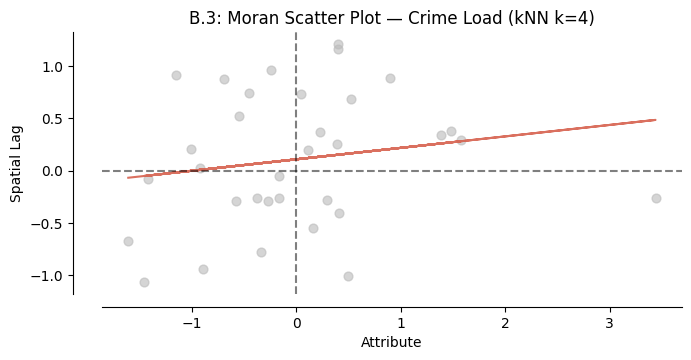

In [51]:
np.random.seed(99)
# ── Build spatial weights (kNN, k=4) and compute Moran's I ─────────────────
y = gdf[CRIME_COL].fillna(0).values.astype(float)
coords = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])

# Initialize the spatial weights matrix using k-Nearest Neighbors
w_knn = KNN.from_array(coords, k=4)
w_knn.transform = "R"  # Row-standardization

# Calculate Global Moran's I
moran = Moran(y, w_knn)
print(f"Moran's I : {moran.I:.4f}")
print(f"p-value   : {moran.p_sim:.4f} (999 permutations)")

# Plot the Moran Scatterplot
fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_title("B.3: Moran Scatter Plot — Crime Load (kNN k=4)")
plt.tight_layout()
plt.show()

> **Note:** The Moran Scatter Plot shows a positive coefficient of **0.1097** ($p\text{-value} = 0.069$).
> This indicates a positive spatial trend, suggesting that communes with similar crime
> rates tend to be geographically grouped. To ensure reproducibility, a random
> seed of **99** was used for the 999 permutations.

<a id='lisa'></a>
## Local Indicators of Spatial Association (LISA) Analysis

The LISA analysis complements the Global Moran's I by identifying **statistically significant local clusters and outliers** ($p < 0.05$) for each individual commune.

This analysis utilizes the same k-Nearest Neighbors (kNN, $k=4$) weights matrix as the global assessment.

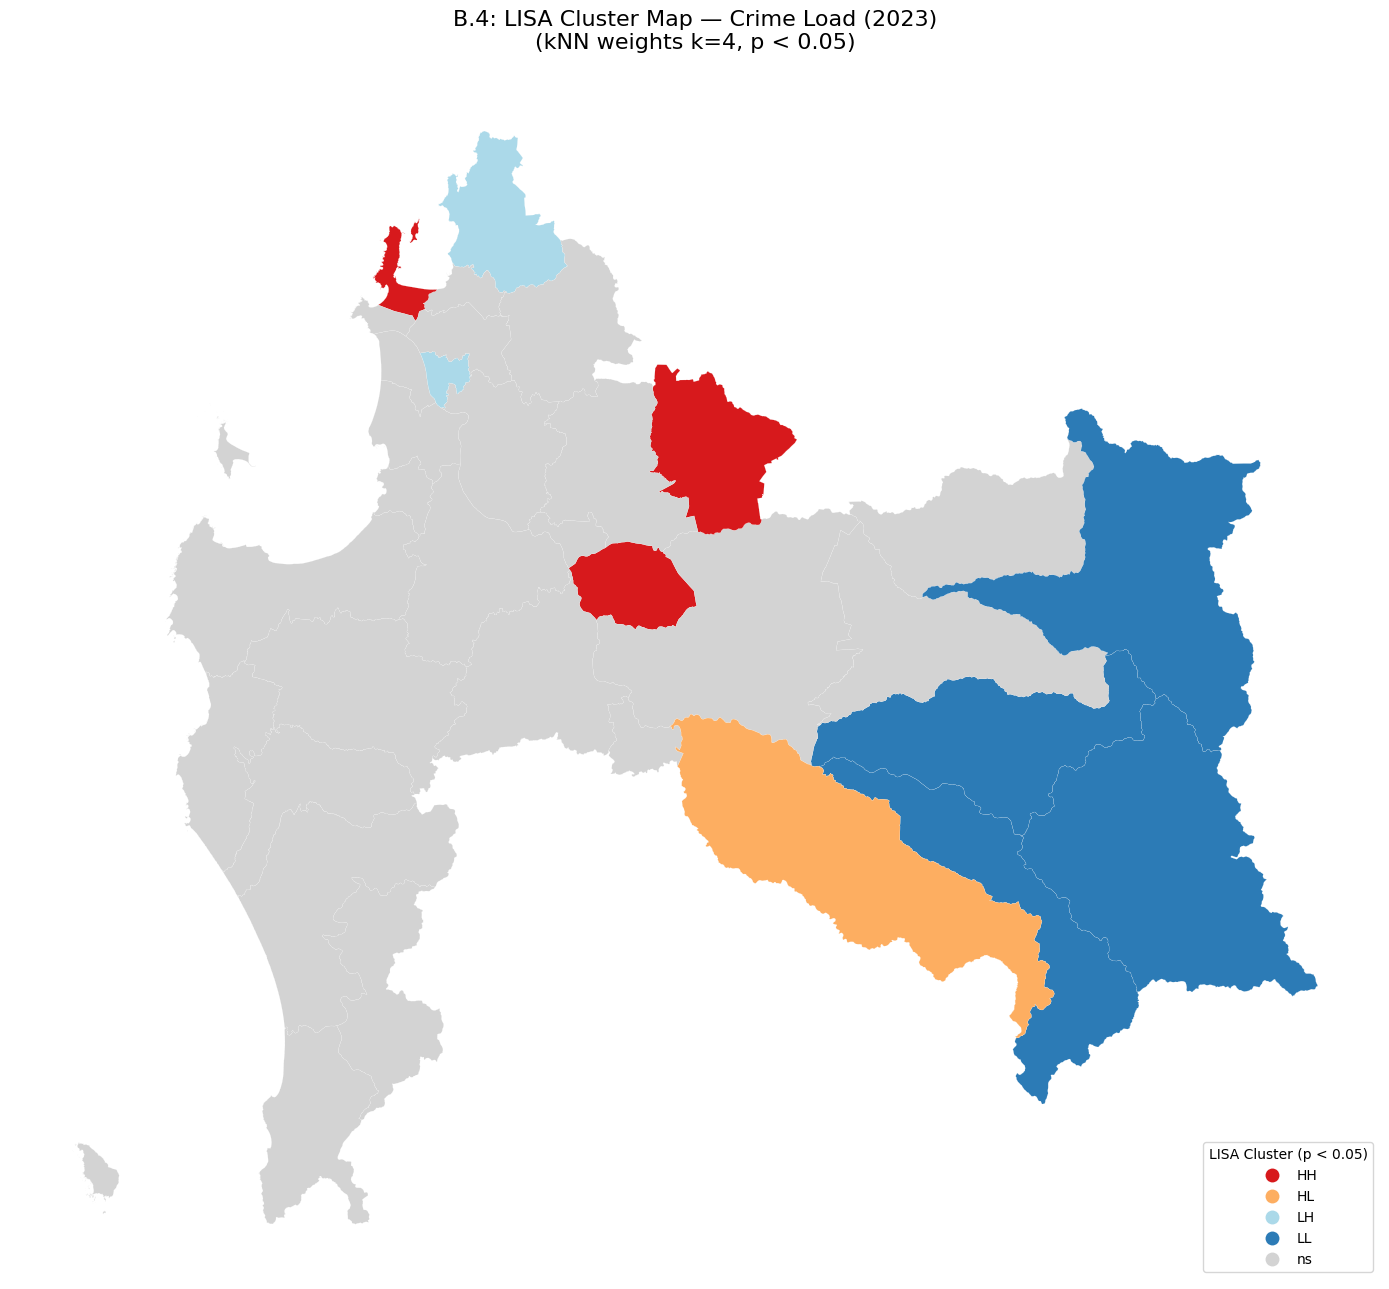

TABLE: Communes with significant LISA clusters (p < 0.05)


,COMUNA,Cluster,F2023,lisa_pvalue
0,Laja,HH (High-High),1154.2,0.018
1,Talcahuano,HH (High-High),1322.8,0.049
2,Cabrero,HH (High-High),1154.0,0.006
3,Chiguayante,LH (Low-High),630.7,0.049
4,Tomé,LH (Low-High),939.6,0.041
5,Quilaco,LL (Low-Low),477.7,0.036
6,Antuco,LL (Low-Low),717.3,0.010
7,Santa Bárbara,LL (Low-Low),907.4,0.044
8,Alto Biobío,LL (Low-Low),529.2,0.001
9,Mulchén,HL (High-Low),1186.2,0.007


In [48]:
# ── LISA (Local Moran's I) ──────────────────────────────────────────────────
np.random.seed(99)
w = KNN.from_dataframe(gdf, k=4)
w.transform = "R" # Row-standardization
lisa = Moran_Local(y, w, permutations=999)

gdf["lisa_cluster"] = lisa.q
gdf["lisa_pvalue"]  = lisa.p_sim
gdf["lisa_signif"]  = lisa.p_sim < 0.05

# ── LISA cluster map ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 18))
ax.set_title(
    "B.4: LISA Cluster Map — Crime Load (2023)\n(kNN weights k=4, p < 0.05)",
    fontsize=16, pad=20
)

lisa_cluster(
    lisa, gdf, p=0.05, ax=ax,
    legend=True,
    legend_kwds={"loc": "lower right", "title": "LISA Cluster (p < 0.05)"},
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

# ── Summary table of significant clusters ───────────────────────────────────
CLUSTER_LABELS = {1: "HH (High-High)", 2: "LH (Low-High)",
                  3: "LL (Low-Low)", 4: "HL (High-Low)"}

signif = (
    gdf[gdf["lisa_signif"]][["COMUNA", CRIME_COL, "lisa_cluster", "lisa_pvalue"]]
    .copy()
)
signif["Cluster"] = signif["lisa_cluster"].map(CLUSTER_LABELS)
signif = (
    signif.sort_values("lisa_cluster")[["COMUNA", "Cluster", CRIME_COL, "lisa_pvalue"]]
    .reset_index(drop=True)
)

print("TABLE: Communes with significant LISA clusters (p < 0.05)")
display(signif.round({CRIME_COL: 1, "lisa_pvalue": 4}))

> **Note on Map Stability:** Local clusters are determined via conditional
> permutation testing. A random seed (`seed=99`) was applied to ensure
> that the classification of clusters (High-High, Low-Low, etc.) remains
> consistent across different environments.

### Interpretation of Significant LISA Clusters

The following table identifies communes with statistically significant spatial patterns ($p < 0.05$). This analysis allows us to move beyond simple data points and identify true geographic trends.

| Cluster Type | Representative Communes | Description |
| :--- | :--- | :--- |
| **HH (High-High)** | **Talcahuano, Laja, Cabrero** | **Hot Spots:** High-crime areas surrounded by high-crime neighbors. These represent regional epicenters of criminal activity. |
| **LL (Low-Low)** | **Alto Biobío, Antuco, Quilaco** | **Cold Spots:** Statistically significant "safe zones" where both the commune and its neighbors have low crime rates. |
| **LH (Low-High)** | **Chiguayante, Tomé** | **Spatial Outliers:** Communes with relatively lower crime rates despite being surrounded by high-crime areas. |
| **HL (High-Low)** | **Mulchén** | **Spatial Outlier:** A "peak" of high crime isolated within a lower-crime geographic context. |

> **Key Insight:** The presence of **Alto Biobío** as a Low-Low cluster with a **p-value of 0.001** indicates an extremely high level of statistical confidence (99.9%) that this area is a legitimate spatial "cold spot."

<a id='discussion'></a>
## B.5 Discussion and Implications

The spatial analysis of the crime load in the Biobío Region (2023) reveals a clear pattern: high-impact social crimes are primarily concentrated in urban and semi-urban areas, while rural areas maintain consistently lower levels.

The analysis identifies two main hotspots: **Greater Concepción** (led by Concepción and Talcahuano) and the **Los Ángeles** sector along with its surrounding communes (Laja and Cabrero). This distribution confirms a strong urban-rural divide, likely associated with higher population density and economic activity.

Although the Global Moran's I indicates a moderate positive spatial trend ($p = 0.069$), the LISA analysis detects **robust local clusters**. The presence of **HH hotspots** in the urban core, a broad **LL coldspot** in the mountain (cordillera) zone, and spatial outliers like **Mulchén (HL)** and **Tomé (LH)** highlights that the most relevant criminal patterns operate at a **local scale**.

### Practical Implications

- **Resource Targeting:** Crime prevention policies should focus resources on significant local hotspots (Greater Concepción and the Los Ángeles–Laja–Cabrero sector), intensifying police presence and community programs.
- **Optimized Allocation:** The mountain coldspot allows for more efficient staffing, reducing intensity in low-incidence communes and reallocating personnel to critical zones.
- **Targeted Research:** Outliers like Mulchén and Tomé require **complementary studies** to identify specific local factors (e.g., transit routes or informal trade) that explain their anomalous behavior.

### Limitations and Future Work

- **Normalization:** The `F2023` variable does not explicitly account for territorial size or population density. Large rural communes may show low rates simply due to lower population concentration.
- **Future Variables:** Future analyses should incorporate **per capita rates**, as well as additional socioeconomic variables (poverty, unemployment) to strengthen the conclusions.